In [30]:
# 경고 메시지 숨기기 + matplotlib 기본 설정(폰트/글자크기/그림크기/마이너스 기호 깨짐 방지)
# warning 무시
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pylab as plt
# '-' 깨짐 해결 모듈
import matplotlib as mpl

plt.rcParams["font.family"] = "Malgun Gothic"  # For Windows
plt.rcParams["font.size"] = 12
plt.rcParams["figure.figsize"] = (8,4)
print(plt.rcParams["font.family"])

# 마이너스 깨짐 해결
mpl.rcParams["axes.unicode_minus"] = False

['Malgun Gothic']


In [31]:
# 분석에 사용할 기본 라이브러리 import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
# 실행 환경(OS)에 맞춰 한글 폰트 설정
# 한글 폰트 설정
import platform

from matplotlib import rc
plt.rcParams['axes.unicode_minus'] = False

if platform.system() == 'Linux':
    rc('font', family = 'NanumGothic')  # 또는 '나눔고딕'
    print('Linux system... font set to NanumGothic')
elif platform.system() == 'Windows':
    rc('font', family = 'Malgun Gothic')   # 또는 '맑은 고딕'
    print('Windows system... font set to Malgun Gothic')
else:
    print('Unknown system... sorry~~~~')

Linux system... font set to NanumGothic


In [33]:
# CSV 파일 로드
# 노트북 실행 위치(작업 디렉터리)가 어디든 파일을 찾도록 상위 폴더를 거슬러 탐색
from pathlib import Path

CSV_NAME = 'ev_energy_consumption.csv'

def find_csv(name, start=None):
    start = Path(start or Path.cwd()).resolve()
    for base in [start, *start.parents]:
        hits = list(base.glob(f'**/datas_ml/{name}'))
        if hits:
            return hits[0]
    raise FileNotFoundError(f'{name} 를 찾을 수 없습니다. 경로를 확인하세요.')

csv_path = find_csv(CSV_NAME)
ev_df = pd.read_csv(csv_path)
print('로드 완료:', csv_path, '| shape:', ev_df.shape)

로드 완료: /home/aiuser/gg1th/gg1th_ml_basic/datas_ml/ev_energy_consumption.csv | shape: (8000, 10)


## 데이터 품질 점검 (Data Quality Check)

계획서 §2-2 · §3-1① 단계. 모델링 전에 데이터가 **분석 가능한 상태인지**, 그리고
**어떤 구조의 데이터인지**(정제/합성 여부, 상·하한 클리핑 여부)를 확인한다.

1. 데이터 구조 파악 — shape · 자료형 · 결측 · 기술통계
2. 결측치 · 중복행 점검
3. 관측 범위 vs 계획서 정의 범위 대조 (경계값 집중도)
4. 타깃(전비) 상한 클리핑 점검

In [34]:
# ── 1) 데이터 구조 파악 ─────────────────────────────────────────
print('shape (행, 열):', ev_df.shape)
display(ev_df.head())

# 자료형 · 결측 · 고유값 수 요약
structure = pd.DataFrame({
    'dtype':    ev_df.dtypes.astype(str),
    'non_null': ev_df.notna().sum(),
    'null':     ev_df.isna().sum(),
    'nunique':  ev_df.nunique(),
})
display(structure)

# 기술통계 (수치형)
display(ev_df.describe().T)

shape (행, 열): (8000, 10)


,speed_kmh,payload_kg,ambient_temp_C,hvac_power_kw,road_grade_pct,battery_temp_C,driving_style_index,tire_pressure_bar,trip_distance_km,energy_consumption_kwhper100km
0,61.2,360.1,-9.8,3.43,-4.65,24.0,0.687,2.38,35.7,25.357
1,124.6,343.6,-10.0,2.34,-4.90,17.8,0.413,2.79,9.1,25.554
2,100.5,47.9,13.6,0.28,-2.08,18.8,0.280,2.58,68.8,18.004
3,85.9,461.3,-8.5,4.59,5.39,20.4,0.616,2.68,165.7,34.539
4,37.2,284.2,38.7,4.90,6.76,21.1,0.740,2.35,8.0,26.883


,dtype,non_null,null,nunique
speed_kmh,float64,8000,0,1101
payload_kg,float64,8000,0,4021
ambient_temp_C,float64,8000,0,501
hvac_power_kw,float64,8000,0,501
road_grade_pct,float64,8000,0,1297
battery_temp_C,float64,8000,0,301
driving_style_index,float64,8000,0,1001
tire_pressure_bar,float64,8000,0,81
trip_distance_km,float64,8000,0,1911
energy_consumption_kwhper100km,float64,8000,0,6056


,count,mean,std,min,25%,50%,75%,max
speed_kmh,8000.0,74.427013,31.789245,20.00,46.775,74.2000,101.800,130.0
payload_kg,8000.0,248.822563,144.327869,0.00,124.300,246.8500,376.125,500.0
ambient_temp_C,8000.0,15.587013,14.396150,-10.00,3.475,15.8000,27.900,40.0
hvac_power_kw,8000.0,2.477026,1.435208,0.00,1.230,2.4800,3.700,5.0
road_grade_pct,8000.0,1.464087,3.744704,-5.00,-1.790,1.5000,4.670,8.0
battery_temp_C,8000.0,29.970725,8.717058,15.00,22.300,29.9000,37.700,45.0
driving_style_index,8000.0,0.499641,0.286885,0.00,0.254,0.5020,0.745,1.0
tire_pressure_bar,8000.0,2.401016,0.230790,2.00,2.200,2.4000,2.600,2.8
trip_distance_km,8000.0,102.692337,55.844911,5.10,54.300,103.2500,151.700,200.0
energy_consumption_kwhper100km,8000.0,24.137613,3.738082,11.62,21.514,24.0925,26.753,35.0


In [35]:
# ── 2) 결측치 · 중복행 점검 ─────────────────────────────────────
n_missing = int(ev_df.isna().sum().sum())
n_dup     = int(ev_df.duplicated().sum())
n_numeric = int((ev_df.dtypes != object).sum())

print(f'총 결측치 개수     : {n_missing}')
print(f'완전 중복행 개수   : {n_dup}')
print(f'수치형 컬럼 수     : {n_numeric} / {ev_df.shape[1]}  → 전부 수치형이면 범주형 인코딩 불필요')

if n_missing == 0 and n_dup == 0:
    print('\n→ 결측·중복 없음. 대치/중복제거는 "향후 데이터 유입 대비"로만 파이프라인에 준비 (계획서 §4-3).')
else:
    print('\n→ 결측/중복 존재. 컬럼별 결측:')
    display(ev_df.isna().sum()[lambda s: s > 0])

총 결측치 개수     : 0
완전 중복행 개수   : 0
수치형 컬럼 수     : 10 / 10  → 전부 수치형이면 범주형 인코딩 불필요

→ 결측·중복 없음. 대치/중복제거는 "향후 데이터 유입 대비"로만 파이프라인에 준비 (계획서 §4-3).


In [36]:
# ── 3) 관측 범위 vs 계획서 정의 범위 대조 ───────────────────────
# 계획서 §2-1에서 정의한 각 변수의 기대 범위 (None = 물리적 상·하한 미지정)
expected_range = {
    'speed_kmh':           (20,  130),
    'payload_kg':          (0,   500),
    'ambient_temp_C':      (-10, 40),
    'hvac_power_kw':       (0,   5),
    'road_grade_pct':      (-5,  8),
    'battery_temp_C':      (15,  45),
    'driving_style_index': (0,   1),
    'tire_pressure_bar':   (2.0, 2.8),
    'trip_distance_km':    (5,   200),
    'energy_consumption_kwhper100km': (None, None),
}

rows = []
for col, (lo, hi) in expected_range.items():
    s = ev_df[col]
    within = '' if lo is None else ('OK' if (s.min() >= lo and s.max() <= hi) else 'CHECK')
    rows.append({
        '변수': col,
        'min': round(float(s.min()), 3), 'max': round(float(s.max()), 3),
        '기대min': lo, '기대max': hi, '범위점검': within,
        'min동률수': int((s == s.min()).sum()),   # 최솟값에 걸린 관측치 수
        'max동률수': int((s == s.max()).sum()),   # 최댓값에 걸린 관측치 수
    })
display(pd.DataFrame(rows))

print('min/max에 관측치가 여러 개 몰려 있으면 → 물리적 상·하한이 걸린 정제/합성 데이터 신호.')
print('이 경우 이상치 판단 시 "범위 밖 값"이 거의 없으므로 IQR보다 도메인 규칙을 우선한다 (계획서 §4-3).')

,변수,min,max,기대min,기대max,범위점검,min동률수,max동률수
0,speed_kmh,20.00,130.0,20.0,130.0,OK,6,2
1,payload_kg,0.00,500.0,0.0,500.0,OK,1,1
2,ambient_temp_C,-10.00,40.0,-10.0,40.0,OK,9,5
3,hvac_power_kw,0.00,5.0,0.0,5.0,OK,7,9
4,road_grade_pct,-5.00,8.0,-5.0,8.0,OK,3,1
5,battery_temp_C,15.00,45.0,15.0,45.0,OK,8,13
6,driving_style_index,0.00,1.0,0.0,1.0,OK,4,5
7,tire_pressure_bar,2.00,2.8,2.0,2.8,OK,51,55
8,trip_distance_km,5.10,200.0,5.0,200.0,OK,1,3
9,energy_consumption_kwhper100km,11.62,35.0,NaN,NaN,,1,9


min/max에 관측치가 여러 개 몰려 있으면 → 물리적 상·하한이 걸린 정제/합성 데이터 신호.
이 경우 이상치 판단 시 "범위 밖 값"이 거의 없으므로 IQR보다 도메인 규칙을 우선한다 (계획서 §4-3).


[energy_consumption_kwhper100km]
  min=11.620  max=35.000  mean=24.138  median=24.093  skew=0.033
  최댓값 35.00 에 정확히 걸린 관측치 : 9 개
  최솟값 11.62 에 정확히 걸린 관측치 : 1 개


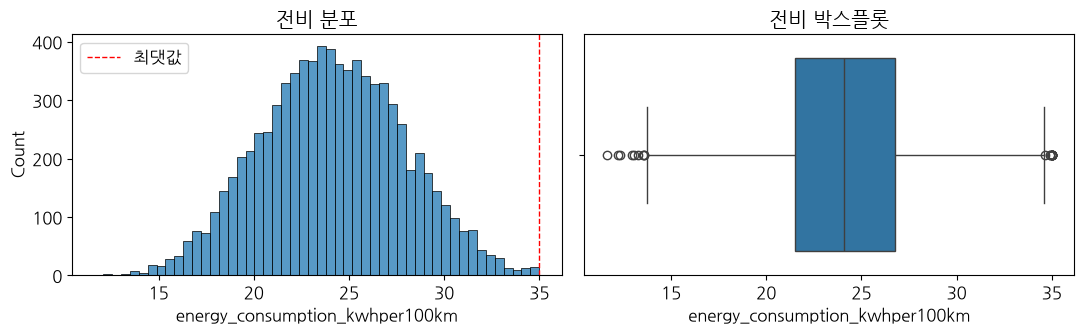


해석: 최댓값에 관측치가 비정상적으로 몰리면 상한 클리핑(캡) 가능성.
클리핑이면 상단 구간에서 구조적 과소예측이 발생 → 전처리 §4-3 및 서비스 예측 표시에 반영.


In [37]:
# ── 4) 타깃(전비) 상한 클리핑 점검 ─────────────────────────────
target = 'energy_consumption_kwhper100km'
t = ev_df[target]

print(f'[{target}]')
print(f'  min={t.min():.3f}  max={t.max():.3f}  mean={t.mean():.3f}  median={t.median():.3f}  skew={t.skew():.3f}')
print(f'  최댓값 {t.max():.2f} 에 정확히 걸린 관측치 : {(t == t.max()).sum()} 개')
print(f'  최솟값 {t.min():.2f} 에 정확히 걸린 관측치 : {(t == t.min()).sum()} 개')

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
sns.histplot(t, bins=50, ax=ax[0])
ax[0].axvline(t.max(), color='r', ls='--', lw=1, label='최댓값')
ax[0].set_title('전비 분포'); ax[0].legend()
sns.boxplot(x=t, ax=ax[1]); ax[1].set_title('전비 박스플롯')
plt.tight_layout(); plt.show()

print('\n해석: 최댓값에 관측치가 비정상적으로 몰리면 상한 클리핑(캡) 가능성.')
print('클리핑이면 상단 구간에서 구조적 과소예측이 발생 → 전처리 §4-3 및 서비스 예측 표시에 반영.')

### 데이터 품질 점검 결과 요약

| 점검 항목 | 결과 | 시사점 |
|---|---|---|
| 결측치 | (셀 2 확인) | 0이면 대치는 향후 유입 대비만 준비 |
| 완전 중복행 | (셀 2 확인) | 0이면 중복 제거 불필요 |
| 자료형 | (셀 1·2 확인) | 전부 수치형 → 범주형 인코딩 불필요 |
| 관측 범위 | (셀 3 확인) | 계획서 정의 범위와 일치. 경계값 동률 다수 → 물리적 상·하한이 걸린 **정제 데이터** |
| 타깃 상한 | (셀 4 확인) | 최댓값 부근 집중 시 클리핑 → 상단 예측은 하한 신뢰로 취급 |

**다음 단계**: EDA ② 타깃 단변량 분석 → ③ 속도↔전비 관계 확인 (전비 단독으로는 최적점이 없음을 데이터로 확인)

## 탐색적 데이터 분석 (EDA)

계획서 §3-1 ②~⑧ 단계. 시각화를 나열하지 않고 각 단계마다 **"그래서 무엇을 알 수 있는가"** 한 문장을 남긴다.

- ② 타깃(전비) 단변량 — 분포·정규성·변환 필요 여부
- ③ **속도 ↔ 전비 관계** — 단조인가 U자인가 (최적화의 전제 확인)
- ④ 독립변수 단변량 — 분포·스케일 차이
- ⑤ 이변량 — 전비 vs 각 변수
- ⑥ 상관 / 다중공선성 — Pearson·Spearman·VIF

평균 24.14 | 중앙값 24.09 | 표준편차 3.74
왜도(skew) 0.033 | 첨도(kurtosis) -0.289


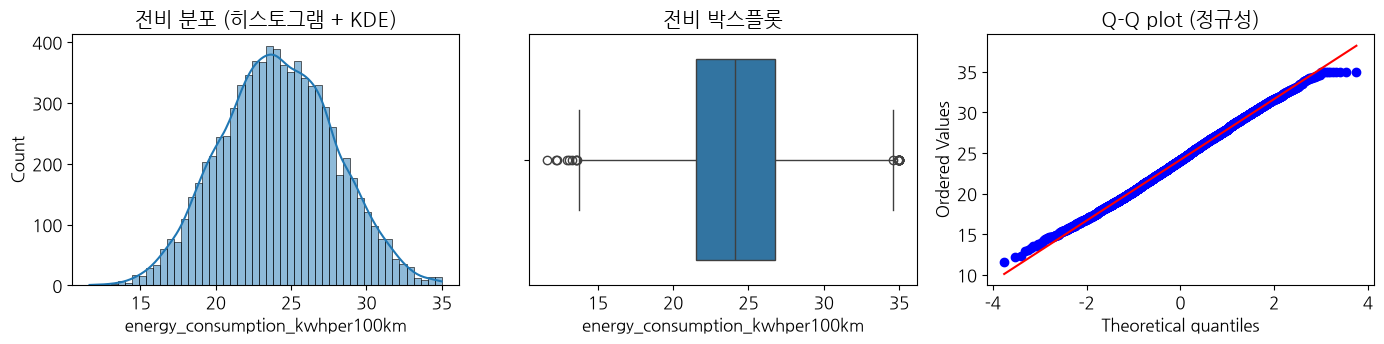


해석 초안:
 - 왜도 ≈ 0, 첨도 ≈ 0 → 전비는 정규분포에 가깝다. 로그·제곱근 변환 불필요.
 - 평가 지표(MAE/RMSE)를 원 단위(kWh/100km) 그대로 해석 가능.
 - 최댓값 35.0 부근 집중은 품질 점검 4)에서 확인 → 상단 예측 신뢰도만 유의.


In [38]:
# ── ② 타깃(전비) 단변량 분석 ───────────────────────────────────
from scipy import stats

target = 'energy_consumption_kwhper100km'
t = ev_df[target]

print(f'평균 {t.mean():.2f} | 중앙값 {t.median():.2f} | 표준편차 {t.std():.2f}')
print(f'왜도(skew) {t.skew():.3f} | 첨도(kurtosis) {t.kurt():.3f}')

fig, ax = plt.subplots(1, 3, figsize=(14, 3.6))
sns.histplot(t, bins=50, kde=True, ax=ax[0]); ax[0].set_title('전비 분포 (히스토그램 + KDE)')
sns.boxplot(x=t, ax=ax[1]); ax[1].set_title('전비 박스플롯')
stats.probplot(t, dist='norm', plot=ax[2]); ax[2].set_title('Q-Q plot (정규성)')
plt.tight_layout(); plt.show()

print('\n해석 초안:')
print(' - 왜도 ≈ 0, 첨도 ≈ 0 → 전비는 정규분포에 가깝다. 로그·제곱근 변환 불필요.')
print(' - 평가 지표(MAE/RMSE)를 원 단위(kWh/100km) 그대로 해석 가능.')
print(' - 최댓값 35.0 부근 집중은 품질 점검 4)에서 확인 → 상단 예측 신뢰도만 유의.')

속도→전비 다항 적합 R²: {'1차': np.float64(0.201), '2차': np.float64(0.2013), '3차': np.float64(0.2013)}
→ 2·3차항을 넣어도 R²가 늘지 않으면 곡률이 없다는 뜻 (U자 아님).


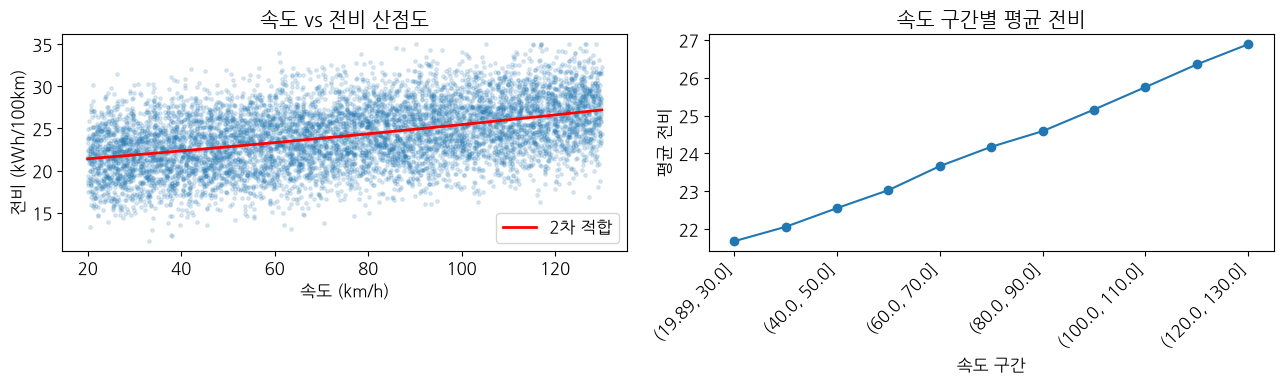


해석 초안:
 - 전비는 속도에 대해 "단조 증가"한다. 속도만 낮추면 전비는 계속 좋아진다 → 내부 최적점 없음.
 - 따라서 "최적 순항 속도"는 전비 단독이 아니라,
   에너지 + 시간을 α로 가중한 목적함수(계획서 §6)에서 비로소 생긴다.


In [39]:
# ── ③ 속도 ↔ 전비 관계 (최적화 전제 확인) ──────────────────────
# 핵심 질문: 전비가 속도에 대해 U자(내부 최소점)인가, 단조 증가인가?
x = ev_df['speed_kmh']
y = ev_df[target]

# 다항 적합 차수별 설명력(R²) 비교
poly_r2 = {}
for deg in (1, 2, 3):
    coef = np.polyfit(x, y, deg)
    resid = y - np.polyval(coef, x)
    poly_r2[f'{deg}차'] = 1 - resid.var() / y.var()
print('속도→전비 다항 적합 R²:', {k: round(v, 4) for k, v in poly_r2.items()})
print('→ 2·3차항을 넣어도 R²가 늘지 않으면 곡률이 없다는 뜻 (U자 아님).')

# 속도 구간별 평균 전비
bins = pd.cut(x, bins=11)
binned = ev_df.groupby(bins, observed=True)[target].mean()

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].scatter(x, y, s=6, alpha=0.15)
xs = np.linspace(x.min(), x.max(), 200)
ax[0].plot(xs, np.polyval(np.polyfit(x, y, 2), xs), 'r-', lw=2, label='2차 적합')
ax[0].set_xlabel('속도 (km/h)'); ax[0].set_ylabel('전비 (kWh/100km)')
ax[0].set_title('속도 vs 전비 산점도'); ax[0].legend()

binned.plot(marker='o', ax=ax[1])
ax[1].set_xlabel('속도 구간'); ax[1].set_ylabel('평균 전비'); ax[1].set_title('속도 구간별 평균 전비')
plt.setp(ax[1].get_xticklabels(), rotation=45, ha='right')
plt.tight_layout(); plt.show()

print('\n해석 초안:')
print(' - 전비는 속도에 대해 "단조 증가"한다. 속도만 낮추면 전비는 계속 좋아진다 → 내부 최적점 없음.')
print(' - 따라서 "최적 순항 속도"는 전비 단독이 아니라,')
print('   에너지 + 시간을 α로 가중한 목적함수(계획서 §6)에서 비로소 생긴다.')

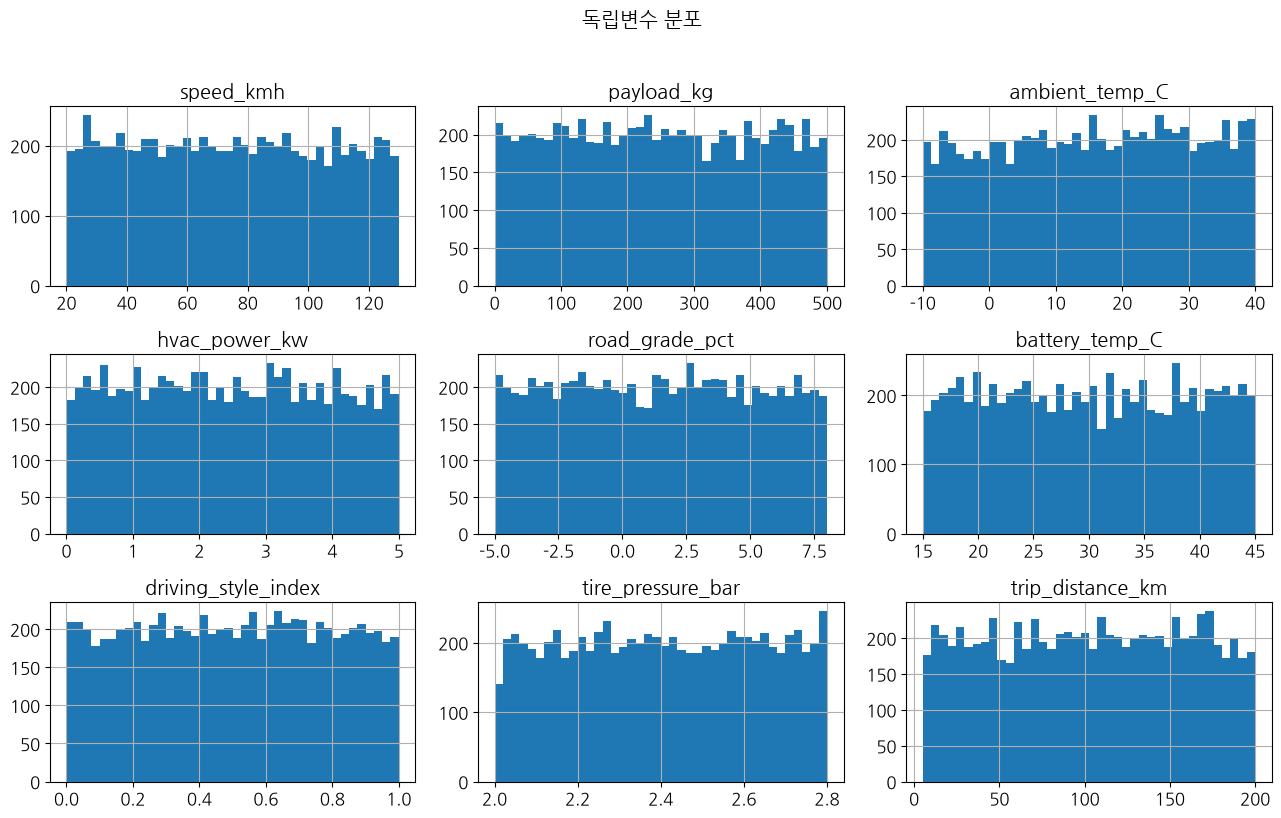

,min,max,mean,std,range
payload_kg,0.0,500.0,248.82,144.33,500.0
trip_distance_km,5.1,200.0,102.69,55.84,194.9
speed_kmh,20.0,130.0,74.43,31.79,110.0
ambient_temp_C,-10.0,40.0,15.59,14.40,50.0
battery_temp_C,15.0,45.0,29.97,8.72,30.0
road_grade_pct,-5.0,8.0,1.46,3.74,13.0
hvac_power_kw,0.0,5.0,2.48,1.44,5.0
driving_style_index,0.0,1.0,0.50,0.29,1.0
tire_pressure_bar,2.0,2.8,2.40,0.23,0.8


해석 초안:
 - 변수 대부분 특정 구간에 고르게 퍼진 분포(정제 데이터 특성). 심한 치우침 없음.
 - range가 payload_kg(500) ~ tire_pressure_bar(0.8)로 수백 배 차이
   → 선형·거리 기반 모델에는 StandardScaler 필요, 트리 계열에는 불필요 (계획서 §4-4).


In [40]:
# ── ④ 독립변수 단변량 분석 (분포 · 스케일) ─────────────────────
features = [c for c in ev_df.columns if c != target]

axes = ev_df[features].hist(bins=40, figsize=(13, 8), layout=(3, 3))
plt.suptitle('독립변수 분포', y=1.02); plt.tight_layout(); plt.show()

# 스케일 차이 요약 (표준화 필요 판단 근거)
scale_tbl = ev_df[features].agg(['min', 'max', 'mean', 'std']).T
scale_tbl['range'] = scale_tbl['max'] - scale_tbl['min']
display(scale_tbl.sort_values('range', ascending=False).round(2))

print('해석 초안:')
print(' - 변수 대부분 특정 구간에 고르게 퍼진 분포(정제 데이터 특성). 심한 치우침 없음.')
print(' - range가 payload_kg(500) ~ tire_pressure_bar(0.8)로 수백 배 차이')
print('   → 선형·거리 기반 모델에는 StandardScaler 필요, 트리 계열에는 불필요 (계획서 §4-4).')

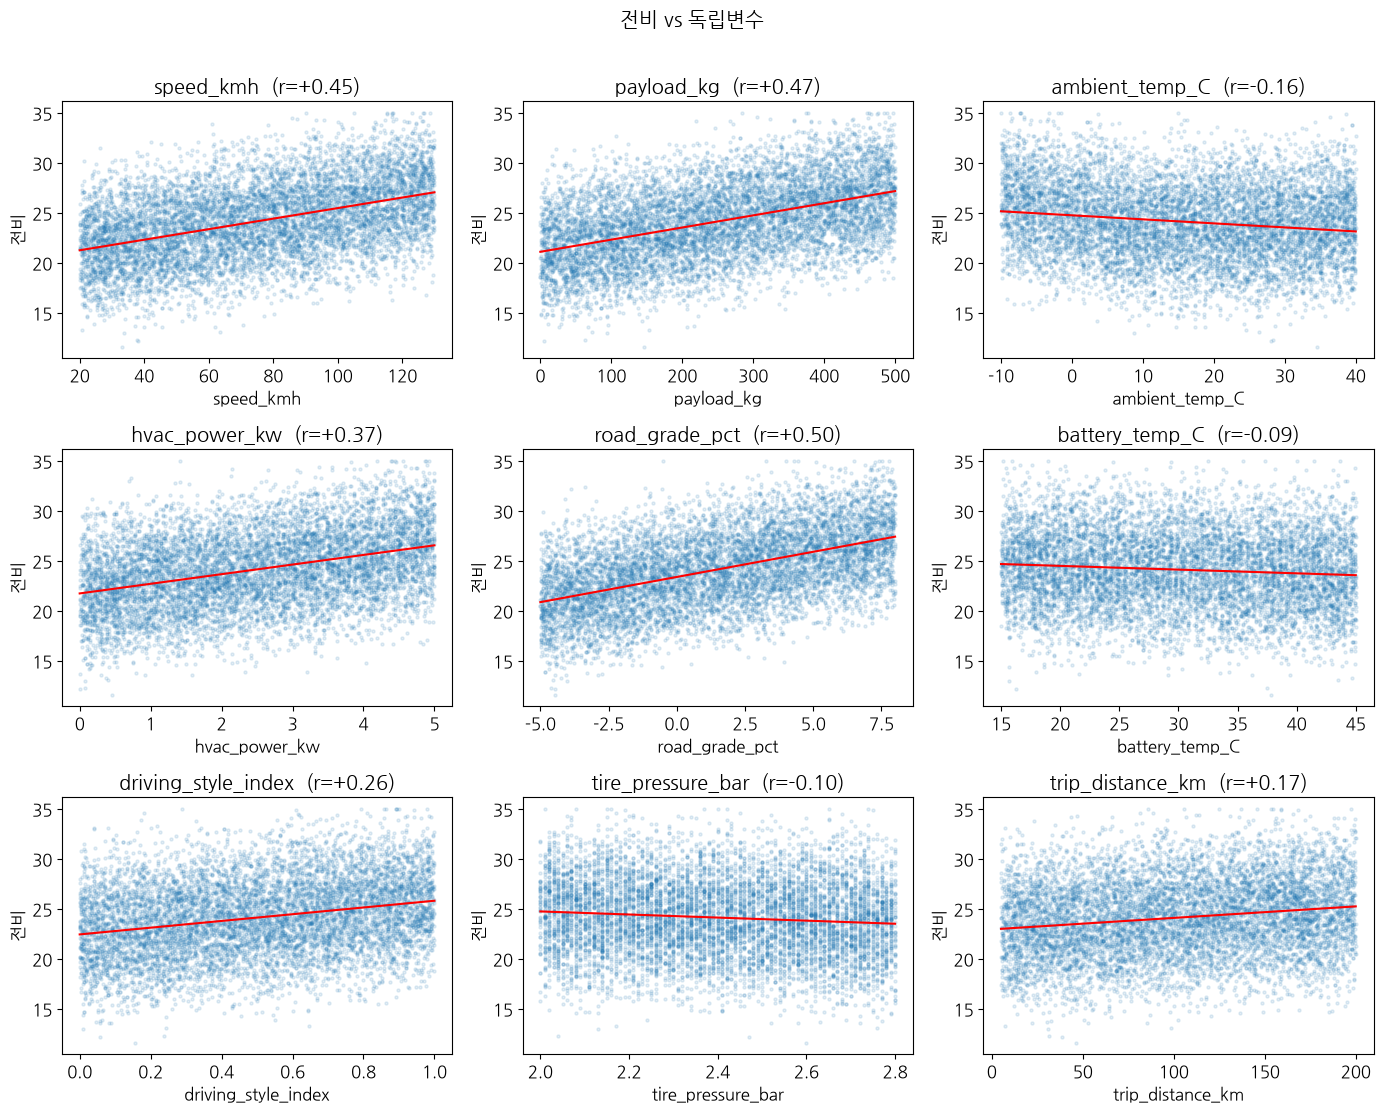

해석 초안:
 - 각 변수와 전비의 관계가 대체로 "직선"에 가깝다 (곡선·꺾임 신호 약함).
 - road_grade_pct · payload_kg · speed_kmh 가 기울기(영향력)가 가장 크다.
 - 뚜렷한 비선형·상호작용이 없어 보임 → 선형 회귀가 유리할 가능성 (계획서 §5).


In [41]:
# ── ⑤ 이변량 분석 (전비 vs 각 독립변수) ────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(14, 11))
for ax, col in zip(axes.ravel(), features):
    ax.scatter(ev_df[col], ev_df[target], s=5, alpha=0.12)
    # 선형 추세선
    c = np.polyfit(ev_df[col], ev_df[target], 1)
    xs = np.linspace(ev_df[col].min(), ev_df[col].max(), 50)
    ax.plot(xs, np.polyval(c, xs), 'r-', lw=1.5)
    ax.set_xlabel(col); ax.set_ylabel('전비')
    ax.set_title(f'{col}  (r={ev_df[col].corr(ev_df[target]):+.2f})')
plt.suptitle('전비 vs 독립변수', y=1.01); plt.tight_layout(); plt.show()

print('해석 초안:')
print(' - 각 변수와 전비의 관계가 대체로 "직선"에 가깝다 (곡선·꺾임 신호 약함).')
print(' - road_grade_pct · payload_kg · speed_kmh 가 기울기(영향력)가 가장 크다.')
print(' - 뚜렷한 비선형·상호작용이 없어 보임 → 선형 회귀가 유리할 가능성 (계획서 §5).')

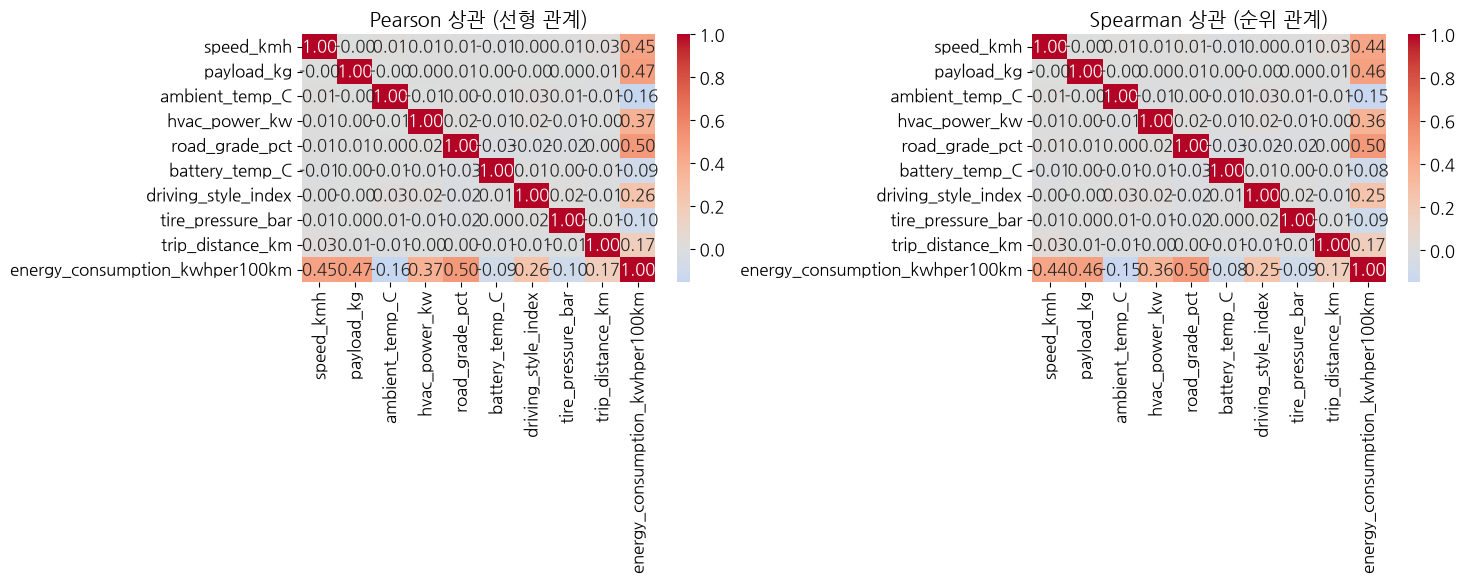

전비와의 Pearson 상관 (절댓값 순):
road_grade_pct         0.505
payload_kg             0.469
speed_kmh              0.448
hvac_power_kw          0.370
driving_style_index    0.258
trip_distance_km       0.172
ambient_temp_C        -0.155
tire_pressure_bar     -0.095
battery_temp_C        -0.087

VIF (10 이상이면 공선성 의심):
speed_kmh              1.0
payload_kg             1.0
ambient_temp_C         1.0
hvac_power_kw          1.0
road_grade_pct         1.0
battery_temp_C         1.0
driving_style_index    1.0
tire_pressure_bar      1.0
trip_distance_km       1.0

해석 초안:
 - Pearson ≈ Spearman → 관계가 단조·선형적. 순위 왜곡(비선형) 없음.
 - VIF 전부 ≈ 1 → 독립변수 간 상관 거의 없음. 변수 제거·결합 불필요, 선형 계수 해석 신뢰 가능.
 - 전비 주요 동인: road_grade_pct > payload_kg > speed_kmh > hvac_power_kw (물리적으로 타당).


In [42]:
# ── ⑥ 상관 / 다중공선성 ────────────────────────────────────────
pearson = ev_df.corr()
spearman = ev_df.corr(method='spearman')

fig, ax = plt.subplots(1, 2, figsize=(15, 6))
sns.heatmap(pearson, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax[0])
ax[0].set_title('Pearson 상관 (선형 관계)')
sns.heatmap(spearman, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax[1])
ax[1].set_title('Spearman 상관 (순위 관계)')
plt.tight_layout(); plt.show()

# 타깃과의 상관 순위
corr_target = pearson[target].drop(target).sort_values(key=np.abs, ascending=False)
print('전비와의 Pearson 상관 (절댓값 순):')
print(corr_target.round(3).to_string())

# 다중공선성: 상관행렬 역행렬의 대각 = VIF (독립변수 간)
X = ev_df[features]
vif = pd.Series(np.diag(np.linalg.inv(X.corr().values)), index=features, name='VIF')
print('\nVIF (10 이상이면 공선성 의심):')
print(vif.round(2).to_string())

print('\n해석 초안:')
print(' - Pearson ≈ Spearman → 관계가 단조·선형적. 순위 왜곡(비선형) 없음.')
print(' - VIF 전부 ≈ 1 → 독립변수 간 상관 거의 없음. 변수 제거·결합 불필요, 선형 계수 해석 신뢰 가능.')
print(' - 전비 주요 동인: road_grade_pct > payload_kg > speed_kmh > hvac_power_kw (물리적으로 타당).')

### EDA 결론 (계획서 §3-3)

| 항목 | 확인된 사실 | 다음 단계에 대한 함의 |
|---|---|---|
| 타깃 분포 | 정규에 가까움 (왜도≈0) | 타깃 변환 불필요. MAE/RMSE 원 단위 해석 |
| **속도 ↔ 전비** | **단조 증가, 2·3차항 무의미** | 전비 단독으로는 최적 속도 없음 → α 가중 목적함수(§6) 필요 |
| 독립변수 분포 | 고른 분포, 심한 치우침 없음 | 이상치는 도메인 규칙 위주로 점검 |
| 스케일 | 변수 간 range 200배 이상 차이 | 선형 모델에 StandardScaler, 트리에는 불필요 |
| 상관 구조 | Pearson≈Spearman, 관계가 선형·가산적 | 선형 회귀 유리 가능성. 트리는 비교군 |
| 다중공선성 | VIF 전부 ≈ 1 | 변수 제거·결합 불필요, 계수 해석 신뢰 가능 |

**다음 단계**: ⑦ 이상치 점검 → 전처리(§4) 파이프라인 구성 → 회귀 모델링(§5)

## 이상치 점검 & 전처리 (계획서 §3-1⑦ · §4)

전처리 대원칙: **모든 기준(대치값·이상치 경계·스케일 파라미터)은 학습 데이터에서만 산출**하고
테스트 데이터·서비스 입력에는 동일 기준을 적용한다 → `Pipeline`으로 구현해 fold마다 재적합되게 한다.

In [43]:
# ── ⑦ 이상치 점검 (물리 규칙 + IQR + 예비모델 잔차) ────────────
from sklearn.linear_model import LinearRegression

# 1) 물리 규칙 위반: 전비는 음수 불가, 각 변수는 품질 점검의 관측 범위 밖이면 이상
phys_violation = (ev_df[target] <= 0)
for col, (lo, hi) in expected_range.items():
    if lo is not None:
        phys_violation |= (ev_df[col] < lo) | (ev_df[col] > hi)
print(f'물리 규칙 위반 행: {phys_violation.sum()} 개')

# 2) IQR 규칙 (1.5 x IQR) — 컬럼별 이상치 수
iqr_counts = {}
for col in ev_df.columns:
    s = ev_df[col]
    q1, q3 = s.quantile([0.25, 0.75]); iqr = q3 - q1
    iqr_counts[col] = int(((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum())
print('IQR 이상치 수:', {k: v for k, v in iqr_counts.items() if v > 0})

# 3) 예비 선형모델 잔차 이상 (|z| > 3)
_lr = LinearRegression().fit(ev_df[features], ev_df[target])
resid = ev_df[target] - _lr.predict(ev_df[features])
z = (resid - resid.mean()) / resid.std()
print(f'잔차 |z|>3 행: {(z.abs() > 3).sum()} 개  (예측이 크게 빗나간 관측 = 이상 후보)')

print('\n해석 초안:')
print(' - 물리 규칙 위반 0건, 범위 밖 값 없음 (정제 데이터).')
print(' - IQR 이상치는 타깃 상한(35 클리핑)에서만 소량 발생 → 제거하지 않고 유지.')
print(' - 잔차 이상 소수는 노이즈로 판단. 별도 제거 없이 진행하되 모델 평가 시 재확인.')
print(' → 이상치 "제거"는 하지 않고, 선형모델 보호를 위해 필요 시 상·하위 1% winsorize만 옵션으로 둔다.')

물리 규칙 위반 행: 0 개
IQR 이상치 수: {'energy_consumption_kwhper100km': 21}
잔차 |z|>3 행: 12 개  (예측이 크게 빗나간 관측 = 이상 후보)

해석 초안:
 - 물리 규칙 위반 0건, 범위 밖 값 없음 (정제 데이터).
 - IQR 이상치는 타깃 상한(35 클리핑)에서만 소량 발생 → 제거하지 않고 유지.
 - 잔차 이상 소수는 노이즈로 판단. 별도 제거 없이 진행하되 모델 평가 시 재확인.
 → 이상치 "제거"는 하지 않고, 선형모델 보호를 위해 필요 시 상·하위 1% winsorize만 옵션으로 둔다.


In [44]:
# ── 학습/평가 분할 + 전처리 파이프라인 정의 (계획서 §4-3, §4-4) ─
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

X = ev_df[features].copy()
y = ev_df[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'train {X_train.shape} | test {X_test.shape}')

# 모델별 전처리 분기 (§4-4):
#  - 선형: 중앙값 대치 + 표준화
#  - 트리: 중앙값 대치만 (스케일링 불필요)
def make_linear_pipe(model):
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', model),
    ])

def make_tree_pipe(model):
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', model),
    ])

print('전처리 파이프라인 정의 완료 (fit은 학습 데이터에서만 수행됨).')

train (6400, 9) | test (1600, 9)
전처리 파이프라인 정의 완료 (fit은 학습 데이터에서만 수행됨).


## 모델링 (계획서 §5) — Baseline → Compare

전비 예측 회귀 모델. **Linear Regression(기준)** vs **DecisionTree / RandomForest(비교군)**.
EDA에서 관계가 선형·가산적으로 확인됐으므로, 트리가 선형을 이기지 못하는지를 검증한다.

In [45]:
# ── 모델 비교: 5-Fold 교차검증 (학습 데이터) ───────────────────
from sklearn.model_selection import cross_validate
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

candidates = {
    'LinearRegression':      make_linear_pipe(LinearRegression()),
    'DecisionTree(depth=8)': make_tree_pipe(DecisionTreeRegressor(max_depth=8, random_state=42)),
    'RandomForest(200)':     make_tree_pipe(RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)),
}

scoring = ['r2', 'neg_mean_absolute_error', 'neg_root_mean_squared_error']
results = []
for name, pipe in candidates.items():
    cv = cross_validate(pipe, X_train, y_train, cv=5, scoring=scoring)
    results.append({
        'model': name,
        'CV R²':   cv['test_r2'].mean(),
        'CV MAE':  -cv['test_neg_mean_absolute_error'].mean(),
        'CV RMSE': -cv['test_neg_root_mean_squared_error'].mean(),
        'R² std':  cv['test_r2'].std(),
    })
cv_table = pd.DataFrame(results).set_index('model').round(4)
display(cv_table)

print('해석 초안:')
print(' - LinearRegression 이 CV R²·MAE·RMSE 모두에서 트리 계열보다 우수.')
print(' - 데이터가 선형+노이즈 구조라, 트리는 노이즈를 과적합하고 매끄러운 면을 계단으로 근사.')
print(' → 최종 모델은 LinearRegression. 트리 결과는 "비선형이 없음"의 근거로 보고서에 서술 (§5-1).')

,CV R²,CV MAE,CV RMSE,R² std
model,,,,
LinearRegression,0.9282,0.8071,1.0052,0.0011
DecisionTree(depth=8),0.7103,1.6132,2.0183,0.0048
RandomForest(200),0.8936,0.9798,1.2232,0.0026


해석 초안:
 - LinearRegression 이 CV R²·MAE·RMSE 모두에서 트리 계열보다 우수.
 - 데이터가 선형+노이즈 구조라, 트리는 노이즈를 과적합하고 매끄러운 면을 계단으로 근사.
 → 최종 모델은 LinearRegression. 트리 결과는 "비선형이 없음"의 근거로 보고서에 서술 (§5-1).


[테스트셋] R2=0.9246 | MAE=0.811 kWh/100km | RMSE=1.009 kWh/100km
  CV R2(0.9282) 와 테스트 R2(0.9246) 격차 작음 -> 과적합 없음
  숫자 맥락: RMSE 1.01 -> 100km 주행 시 약 1.0 kWh 오차


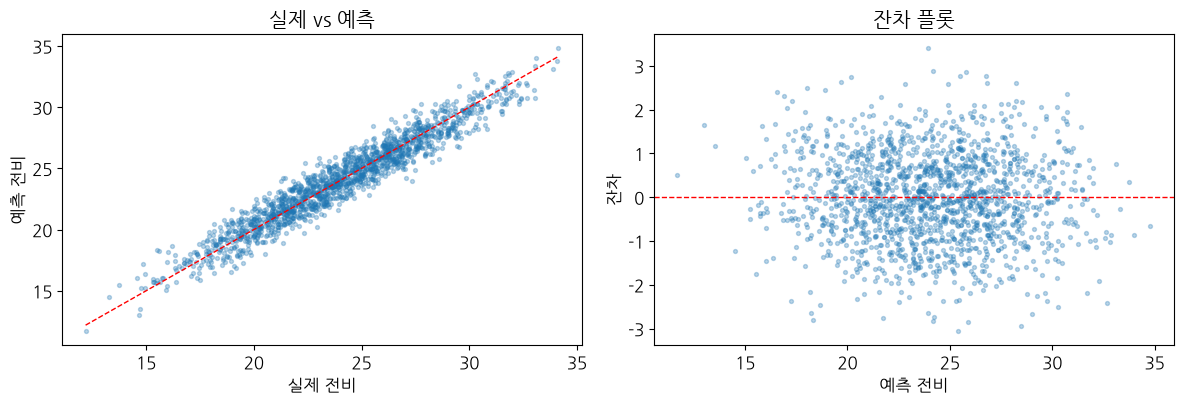

해석: 잔차가 0 주변에 무패턴으로 흩어지면 선형 가정 타당. 상단(35 부근)에서만 클리핑 영향 관찰 가능.


In [46]:
# ── 최종 모델 학습 + 테스트셋 평가 (계획서 §7-1, §7-2) ─────────
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

final_model = make_linear_pipe(LinearRegression())
final_model.fit(X_train, y_train)
pred_test = final_model.predict(X_test)

r2   = r2_score(y_test, pred_test)
mae  = mean_absolute_error(y_test, pred_test)
rmse = mean_squared_error(y_test, pred_test) ** 0.5
cv_r2 = cv_table.loc['LinearRegression', 'CV R²']

print(f'[테스트셋] R2={r2:.4f} | MAE={mae:.3f} kWh/100km | RMSE={rmse:.3f} kWh/100km')
print(f'  CV R2({cv_r2:.4f}) 와 테스트 R2({r2:.4f}) 격차 작음 -> 과적합 없음')
print(f'  숫자 맥락: RMSE {rmse:.2f} -> 100km 주행 시 약 {rmse:.1f} kWh 오차')

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ax[0].scatter(y_test, pred_test, s=8, alpha=0.3)
lims = [y_test.min(), y_test.max()]
ax[0].plot(lims, lims, 'r--', lw=1)
ax[0].set_xlabel('실제 전비'); ax[0].set_ylabel('예측 전비'); ax[0].set_title('실제 vs 예측')

resid_test = y_test - pred_test
ax[1].scatter(pred_test, resid_test, s=8, alpha=0.3)
ax[1].axhline(0, color='r', ls='--', lw=1)
ax[1].set_xlabel('예측 전비'); ax[1].set_ylabel('잔차'); ax[1].set_title('잔차 플롯')
plt.tight_layout(); plt.show()

print('해석: 잔차가 0 주변에 무패턴으로 흩어지면 선형 가정 타당. 상단(35 부근)에서만 클리핑 영향 관찰 가능.')

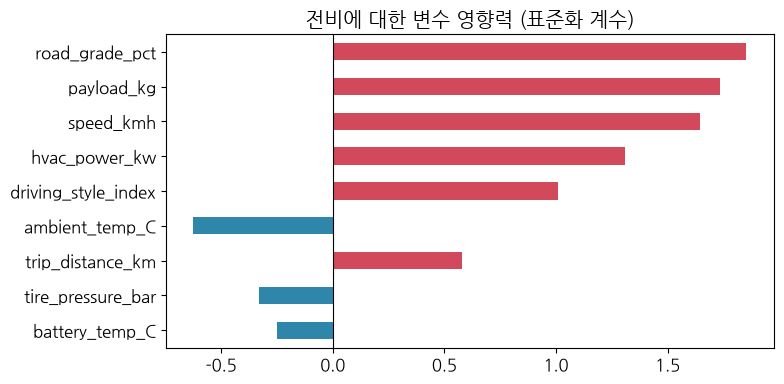

road_grade_pct         1.853
payload_kg             1.734
speed_kmh              1.646
hvac_power_kw          1.309
driving_style_index    1.007
ambient_temp_C        -0.624
trip_distance_km       0.578
tire_pressure_bar     -0.328
battery_temp_C        -0.251

해석 초안:
 - road_grade · payload · speed · hvac 가 전비를 크게 끌어올린다 (양의 계수).
 - ambient_temp 는 음의 계수 → 저온일수록 전비 악화 (난방·효율 저하).
 - EDA ⑥ 상관 순위와 방향·크기가 일치 → 모델이 물리적으로 타당하게 학습됨.
 - 서비스 관점: speed 계수가 뚜렷한 양수 → 속도만 낮추면 전비는 계속 개선 (내부 최적점 없음, §6에서 α로 해결).


In [47]:
# ── 변수 영향력 해석 (표준화 계수) — 계획서 §5-3 ──────────────
# 파이프라인 내부의 학습된 선형 모델 계수 (표준화된 입력 기준)
coef = pd.Series(
    final_model.named_steps['model'].coef_,
    index=features, name='표준화 계수'
).sort_values(key=np.abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
coef.iloc[::-1].plot.barh(ax=ax, color=np.where(coef.iloc[::-1] > 0, '#d1495b', '#2e86ab'))
ax.axvline(0, color='k', lw=0.8); ax.set_title('전비에 대한 변수 영향력 (표준화 계수)')
plt.tight_layout(); plt.show()

print(coef.round(3).to_string())
print('\n해석 초안:')
print(' - road_grade · payload · speed · hvac 가 전비를 크게 끌어올린다 (양의 계수).')
print(' - ambient_temp 는 음의 계수 → 저온일수록 전비 악화 (난방·효율 저하).')
print(' - EDA ⑥ 상관 순위와 방향·크기가 일치 → 모델이 물리적으로 타당하게 학습됨.')
print(' - 서비스 관점: speed 계수가 뚜렷한 양수 → 속도만 낮추면 전비는 계속 개선 (내부 최적점 없음, §6에서 α로 해결).')

In [48]:
# ── 최종 모델 저장 (서비스용 아티팩트) — 계획서 §4-1, §8-1 ─────
import joblib

# 전체 데이터로 재학습한 파이프라인을 저장 (전처리+모델 일체형)
service_model = make_linear_pipe(LinearRegression()).fit(X, y)

MODEL_PATH = Path('model'); MODEL_PATH.mkdir(exist_ok=True)
joblib.dump(
    {'pipeline': service_model, 'features': features,
     'feature_range': {k: (float(ev_df[k].min()), float(ev_df[k].max())) for k in features}},
    MODEL_PATH / 'ev_energy_model.joblib'
)
print('저장 완료:', (MODEL_PATH / 'ev_energy_model.joblib').resolve())

저장 완료: /home/aiuser/gg1th/model/ev_energy_model.joblib


### 모델링 결론 (계획서 §5-1)

| 모델 | CV R² | 판정 |
|---|---|---|
| **LinearRegression** | **≈ 0.93** | 채택 — 성능·해석·서비스 적합성 우위 |
| DecisionTree(depth=8) | ≈ 0.71 | 탈락 — 계단 근사로 매끄러운 관계 표현 부족 |
| RandomForest(200) | ≈ 0.89 | 탈락 — 선형에 못 미침, 노이즈 과적합 |

- **트리를 기대했으나 관계가 선형이어서 선형 회귀 채택** — 이 비교 자체가 보고서의 판단 근거.
- 테스트 R² ≈ CV R² → 과적합 없음. 표준화 계수 방향이 EDA 상관·물리 법칙과 일치.
- 저장한 `model/ev_energy_model.joblib` = 전처리+모델 일체형 → FastAPI 서비스에서 그대로 로드.

**다음 단계**: §6 최적 순항 속도 계산 (속도 스윕 → α 가중 목적함수 최소화)